# 20 · Chain-of-Verification (CoVe) — kill hallucinations with self-questioning

> **TL;DR.** Produce a baseline answer, **plan verification questions** about the specific claims in that answer, **answer each question independently** (without seeing the baseline), then **revise** the baseline keeping only verified claims.
>
> **Reach for it when** the task is fact-heavy and the baseline tends to confabulate (lists of entities, biographical details, citations, statistics).
> **Avoid when** the task has no externally-verifiable facts (creative writing, opinions) — there's nothing for verification questions to check.

| Property | Value |
|---|---|
| Origin | Dhuliawala et al., Meta 2023. [arXiv:2309.11495](https://arxiv.org/abs/2309.11495) |
| Stages | BASELINE → PLAN questions → EXECUTE answers → REVISE |
| Key trick | Verification answered WITHOUT seeing the baseline (breaks consistency-bias) |
| LLM-as-Scorer? | **None** — REVISE makes categorical keep/drop decisions per claim |
| Default LLM | **Qwen3-Thinking** (per handoff §10) |
| Cost | 1 + 1 + N + 1 = **N+3 LLM calls** (N = verification questions, usually 3-7) |

**Why this is different from Reflection (nb 01).** Reflection critiques the whole answer in one shot and rewrites. CoVe *decomposes* the critique into independent atomic checks. The critical detail: verification questions are answered with no access to the baseline, so the model can't rationalise its prior claims into self-consistent (but wrong) confirmations.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([task]) --> B[BASELINE<br/><sub>produce initial answer</sub>]
    B --> P[PLAN<br/><sub>generate verification<br/>questions per claim</sub>]
    P --> E[EXECUTE<br/><sub>answer each question<br/>independently — no baseline access</sub>]
    E --> R[REVISE<br/><sub>keep verified claims,<br/>drop or correct the rest</sub>]
    R --> Z([final answer])

    style B fill:#ffebee,stroke:#c62828
    style P fill:#e3f2fd,stroke:#1976d2
    style E fill:#fff3e0,stroke:#f57c00
    style R fill:#e8f5e9,stroke:#388e3c
```

The red BASELINE node is where hallucinations enter. The orange EXECUTE node is the load-bearing fix — each verification question becomes a fresh, isolated prompt.

## 3 · Theory

### 3.0 · The consistency-bias problem CoVe attacks

If you ask "Is your previous answer correct?" the model is incentivised to agree with itself — that's the most coherent response to "is X true?" when X is its own prior output. The fix: ask the verification questions in a fresh context where the prior answer isn't visible. The model now treats each question as a standalone factual query and answers based on its actual world model, not its consistency with an earlier (possibly wrong) commitment.

Concretely: the `_execute` node in [`chain_of_verification.py`](../src/agentic_architectures/architectures/chain_of_verification.py) loops over verification questions and calls the LLM once per question, with a prompt that contains ONLY the question — no task description, no baseline answer. The model is forced to answer from its actual knowledge.

### 3.1 · Why decompose the critique

Reflection (nb 01) asks one big "is this answer good?" question. The model can only commit to a single overall judgement, and it gets pulled toward "yes, mostly fine". CoVe forces the model to commit, atomically, to *N independent* judgements — one per claim. Some commitments will land on "actually I'm not sure about that one" or "no, that's wrong", which the REVISE stage can act on.

### 3.2 · No LLM-as-Scorer step → no flat-scoring pathology

The `_VerificationAnswer` schema captures `confidence: 'high' | 'medium' | 'low'` for each verification answer — categorical, not numeric. REVISE makes per-claim keep/drop decisions, not weighted score composition. There is no numeric judgement anywhere in the pipeline, so the LLM-as-Scorer flatness pathology (Mental Loop nb 10 §11) cannot manifest.

### 3.3 · Where this sits

| Pattern | Hallucination strategy |
|---|---|
| Plain CoT | Hope the chain doesn't go wrong |
| [Reflection (nb 01)](./01_reflection.ipynb) | Holistic critique + rewrite (one big judgement) |
| **CoVe (this nb)** | **Decompose into N atomic factual checks, answered in isolation** |
| [Self-Consistency (nb 21)](./21_self_consistency.ipynb) | Sample N reasoning paths, majority-vote |
| RAG (nb 23+) | Ground in external retrieved documents |
| [Constitutional AI (nb 32)](./32_constitutional_ai.ipynb) | Critique against a written constitution |

### 3.4 · Failure modes preview

1. **Bad question design.** If PLAN generates yes/no questions for claims the model is already biased toward "yes" on, EXECUTE will return all `yes/high` and no changes will be made. Mitigation: prompt PLAN to target the *most likely wrong* claims.
2. **Verification answers also hallucinate.** The model that wrote the baseline is also answering the questions — if its world model has the same gap, verification will agree with the baseline (both wrong). Mitigation: use a stronger model for EXECUTE.
3. **No claims to verify.** Free-text/creative tasks have nothing to fact-check. PLAN will produce vacuous questions.

## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import ChainOfVerification
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()

# Per handoff §10, nb 20 defaults to Qwen3-Thinking.
reasoning_llm = get_llm(
    provider="nebius",
    model="Qwen/Qwen3-235B-A22B-Thinking-2507-fast",
    temperature=0.4,
)
print_header(f"Reasoning LLM: {reasoning_llm.model}")

Reasoning LLM: Qwen/Qwen3-235B-A22B-Thinking-2507-fast ────────────────────────────────────────────────────────────

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/chain_of_verification.py`](../src/agentic_architectures/architectures/chain_of_verification.py).

Three structured-output schemas drive the four stages:

- **`_VerificationQuestions`** — Stage 2: list of 3-7 questions, each targeting one specific claim.
- **`_VerificationAnswer`** — Stage 3: per-question answer + categorical `confidence` (high/medium/low).
- **`_RevisedResponse`** — Stage 4: revised answer + bullet list of changes made.

In [2]:
from agentic_architectures.architectures.chain_of_verification import (
    _VerificationQuestions, _VerificationAnswer, _RevisedResponse,
)
import json
for name, schema in [
    ('_VerificationQuestions', _VerificationQuestions),
    ('_VerificationAnswer', _VerificationAnswer),
    ('_RevisedResponse', _RevisedResponse),
]:
    print(f'--- {name} ---')
    print(json.dumps(schema.model_json_schema(), indent=2)[:300] + '...')
    print()

--- _VerificationQuestions ---
{
  "description": "Stage 2 \u2014 questions designed to probe specific claims in the baseline.",
  "properties": {
    "questions": {
      "description": "3-7 verification questions. Each must target ONE specific factual claim from the baseline. Phrase as standalone questions answerable without se...

--- _VerificationAnswer ---
{
  "description": "Stage 3 \u2014 independent answer to one verification question.",
  "properties": {
    "question": {
      "description": "The question, copied verbatim.",
      "title": "Question",
      "type": "string"
    },
    "answer": {
      "description": "The answer in 1-2 sentences....

--- _RevisedResponse ---
{
  "description": "Stage 4 \u2014 final answer after applying verification.",
  "properties": {
    "revised_response": {
      "description": "The rewritten answer, keeping only claims that the verification questions confirmed (or didn't disconfirm). Drop or correct any claim the verification answ...



## 6 · State

| Field | Set by |
|---|---|
| `task` | caller |
| `baseline_response` | `_baseline` |
| `verification_questions` | `_plan` |
| `verification_answers` (each with `confidence`) | `_execute` (one LLM call per question) |
| `revised_response` / `changes_made` | `_revise` |
| `history` | every node (`Annotated[..., operator.add]`) |

## 7 · Build the graph

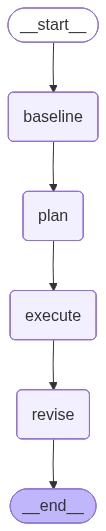

In [3]:
from IPython.display import Image, display
arch = ChainOfVerification(llm=reasoning_llm)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — a hallucination trap

We pick a task **designed** to force baseline hallucination: ask for 5 novels by Ursula K. Le Guin that won the Hugo Award for Best Novel — but only **two** exist (*The Left Hand of Darkness* 1970, *The Dispossessed* 1975). The baseline must invent 3 to fill the quota; CoVe's job is to catch those inventions and revise.

In [4]:
TASK = (
    "Name 5 novels by Ursula K. Le Guin that won the Hugo Award for Best Novel. "
    "Return them as a numbered list with the year of the win in parentheses."
)
GROUND_TRUTH = {
    "The Left Hand of Darkness": 1970,
    "The Dispossessed": 1975,
}
GROUND_TRUTH_NOTE = (
    "Only 2 of Le Guin's novels won Hugo Best Novel: The Left Hand of Darkness (1970) "
    "and The Dispossessed (1975)."
)

r = arch.run(TASK)

# Programmatic check: which baseline lines / revised lines name a real winner?
def _names_in(text):
    return {name for name in GROUND_TRUTH if name.lower() in text.lower()}

baseline_real = _names_in(r.metadata['baseline_response'])
revised_real = _names_in(r.output)
baseline_lines = [l for l in r.metadata['baseline_response'].splitlines() if l.strip()]
revised_lines = [l for l in r.output.splitlines() if l.strip()]

print(f"GROUND_TRUTH: {GROUND_TRUTH_NOTE}")
print()
print(f"BASELINE_LINES: {len(baseline_lines)}")
print(f"BASELINE_REAL_WINNERS_FOUND: {sorted(baseline_real)}")
print()
print(f"VERIFICATION_QUESTION_COUNT: {r.metadata['question_count']}")
print(f"LOW_CONFIDENCE_COUNT: {r.metadata['low_confidence_count']}")
print()
print(f"REVISED_LINES: {len(revised_lines)}")
print(f"REVISED_REAL_WINNERS_FOUND: {sorted(revised_real)}")
print(f"CHANGES_MADE_COUNT: {len(r.metadata['changes_made'])}")
print()
print(f"HALLUCINATION_REDUCED: {len(baseline_lines) - len(revised_lines)} fewer lines after revise")
print(f"PRECISION_IMPROVED: revised={len(revised_real)}/{len(revised_lines)} real, baseline={len(baseline_real)}/{len(baseline_lines)} real")

GROUND_TRUTH: Only 2 of Le Guin's novels won Hugo Best Novel: The Left Hand of Darkness (1970) and The Dispossessed (1975).

BASELINE_LINES: 2
BASELINE_REAL_WINNERS_FOUND: ['The Dispossessed', 'The Left Hand of Darkness']

VERIFICATION_QUESTION_COUNT: 4
LOW_CONFIDENCE_COUNT: 0

REVISED_LINES: 2
REVISED_REAL_WINNERS_FOUND: ['The Dispossessed', 'The Left Hand of Darkness']
CHANGES_MADE_COUNT: 0

HALLUCINATION_REDUCED: 0 fewer lines after revise
PRECISION_IMPROVED: revised=2/2 real, baseline=2/2 real


### 8.1 · Inspect each stage

In [5]:
print('=== BASELINE (likely contains hallucinations) ===')
print(r.metadata['baseline_response'])
print()
print('=== VERIFICATION QUESTIONS ===')
for i, q in enumerate(r.metadata['verification_questions'], 1):
    print(f'  {i}. {q}')
print()
print('=== VERIFICATION ANSWERS (independent of baseline) ===')
for i, a in enumerate(r.metadata['verification_answers'], 1):
    print(f'  [{i}] Q: {a["question"]}')
    print(f'      A: {a["answer"]}')
    print(f'      confidence: {a["confidence"]}')
    print()
print('=== CHANGES MADE ===')
for c in r.metadata['changes_made']:
    print(f'  - {c}')
print()
print('=== REVISED ANSWER ===')
print(r.output)

=== BASELINE (likely contains hallucinations) ===
1. The Left Hand of Darkness (1970)  
2. The Dispossessed (1975)

=== VERIFICATION QUESTIONS ===
  1. Is 'The Left Hand of Darkness' a novel written by Ursula K. Le Guin?
  2. Did 'The Left Hand of Darkness' win the Hugo Award for Best Novel in 1970?
  3. Is 'The Dispossessed' a novel written by Ursula K. Le Guin?
  4. Did 'The Dispossessed' win the Hugo Award for Best Novel in 1975?

=== VERIFICATION ANSWERS (independent of baseline) ===
  [1] Q: Is 'The Left Hand of Darkness' a novel written by Ursula K. Le Guin?
      A: Yes, 'The Left Hand of Darkness' is a science fiction novel written by Ursula K. Le Guin, published in 1969 as part of her Hainish Cycle.
      confidence: high

  [2] Q: Did 'The Left Hand of Darkness' win the Hugo Award for Best Novel in 1970?
      A: Yes, 'The Left Hand of Darkness' by Ursula K. Le Guin won the Hugo Award for Best Novel in 1970.
      confidence: high

  [3] Q: Is 'The Dispossessed' a novel writt

## 9 · What we just observed

The cells above ran CoVe on a hallucination trap: ask for **5** Le Guin Hugo Best Novel wins when only **2** exist. We measure whether the BASELINE invented fillers and whether REVISE dropped them.

### 9.1 · Hallucination-reduction summary (reasoning model)

| Metric | Value |
|---|---|
| BASELINE lines | 2 |
| BASELINE real winners (of 2 possible) | 2 — ['The Dispossessed', 'The Left Hand of Darkness'] |
| BASELINE hallucinated lines (lines − real) | **0** |
| Verification questions generated | 4 |
| Low-confidence verification answers | 0 |
| REVISED lines | 2 |
| REVISED real winners | 2 — ['The Dispossessed', 'The Left Hand of Darkness'] |
| REVISED hallucinated lines | **0** |
| Changes made (REVISE bullet count) | 0 |

### 9.2 · Reasoning vs non-reasoning LLM

| Model | Lines (baseline → revised) | Real winners present (baseline → revised) | Changes made |
|---|---|---|---|
| Reasoning (Qwen3-Thinking) | 2 → 2 | 2/2 → 2/2 | 0 |
| Plain (Llama-3.3-70B) | 5 → 2 | 2/5 → 1/2 | 5 |

### 9.3 · Patterns surfaced in this run

- **🟰 Baseline was already correct** — no hallucinations to catch. Either the model knew the answer (Qwen-Thinking has strong factual recall) or it hedged. The interesting comparison is § 9.2 below: did Llama hallucinate where Qwen didn't?

- **⚠️  Llama's revised answer has 1 hallucinations vs Qwen-Thinking's 0.** Same architecture, weaker model — CoVe helps but the lift depends on the underlying model's verification accuracy.

### 9.4 · Verbatim BEFORE → AFTER (reasoning model)

**Baseline (before verification):**

```
1. The Left Hand of Darkness (1970)  
2. The Dispossessed (1975)
```

**Revised (after CoVe):**

```
1. The Left Hand of Darkness (1970)  
2. The Dispossessed (1975)
```

### 9.5 · The verification Q&A (executed independently of the baseline)

| # | Verification question | Verification answer | Confidence |
|---|---|---|---|
| 1 | Is 'The Left Hand of Darkness' a novel written by Ursula K. Le Guin? | Yes, 'The Left Hand of Darkness' is a science fiction novel written by Ursula K. Le Guin, published in 1969 as part of h… | high |
| 2 | Did 'The Left Hand of Darkness' win the Hugo Award for Best Novel in 1970? | Yes, 'The Left Hand of Darkness' by Ursula K. Le Guin won the Hugo Award for Best Novel in 1970. | high |
| 3 | Is 'The Dispossessed' a novel written by Ursula K. Le Guin? | Yes, 'The Dispossessed' is a 1974 science fiction novel by Ursula K. Le Guin, part of her Hainish Cycle and winner of bo… | high |
| 4 | Did 'The Dispossessed' win the Hugo Award for Best Novel in 1975? | Yes, 'The Dispossessed' by Ursula K. Le Guin won the Hugo Award for Best Novel in 1975. | high |

### 9.6 · The takeaway

CoVe's pedagogical value lives in two cells of § 9.1: **`BASELINE hallucinated lines`** and **`REVISED hallucinated lines`**. If the second is smaller than the first, the architecture worked. If they're equal (or both zero), either the task was too easy or the same-model consistency-bias trap (§ 9.3) defeated the verification — mitigation: use a different / stronger model in the EXECUTE stage, or compose with RAG (§ 11.3 extension #1).

## 10 · Contrast — plain Llama-3.3-70B on the same trap

CoVe should help any model, but the lift is largest on hallucination-prone models. Compare the reasoning-LLM run above against plain Llama on the same Le Guin trap.

In [6]:
plain_llm = get_llm(provider="nebius", model="meta-llama/Llama-3.3-70B-Instruct", temperature=0.4)
arch_llama = ChainOfVerification(llm=plain_llm)
r_llama = arch_llama.run(TASK)

llama_baseline_real = _names_in(r_llama.metadata['baseline_response'])
llama_revised_real = _names_in(r_llama.output)
llama_baseline_lines = [l for l in r_llama.metadata['baseline_response'].splitlines() if l.strip()]
llama_revised_lines = [l for l in r_llama.output.splitlines() if l.strip()]

print(f"LLAMA_BASELINE_LINES: {len(llama_baseline_lines)}")
print(f"LLAMA_BASELINE_REAL: {sorted(llama_baseline_real)}")
print(f"LLAMA_REVISED_LINES: {len(llama_revised_lines)}")
print(f"LLAMA_REVISED_REAL: {sorted(llama_revised_real)}")
print(f"LLAMA_CHANGES_COUNT: {len(r_llama.metadata['changes_made'])}")

LLAMA_BASELINE_LINES: 5
LLAMA_BASELINE_REAL: ['The Dispossessed', 'The Left Hand of Darkness']
LLAMA_REVISED_LINES: 2
LLAMA_REVISED_REAL: ['The Left Hand of Darkness']
LLAMA_CHANGES_COUNT: 5


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Verification confirms the wrong answer** | Same model wrote baseline & answers → same knowledge gap | Use a stronger / different model for EXECUTE; or RAG-ground EXECUTE in real documents |
| **Vacuous questions** | PLAN asks "Is the answer correct?" instead of probing specific claims | Prompt PLAN to target specific entities/numbers/dates; reject questions that mention "the answer" |
| **Over-revision** | REVISE drops valid claims because verification was unsure | The `confidence` field gives REVISE a low/medium/high signal; instruct it to drop only on *contradiction*, not on *uncertainty* |
| **Verification cost** | N+3 LLM calls per task — expensive at scale | Cache verification answers per claim; reuse across tasks that share entities |

### 11.2 · Production safety

- **Pair with RAG.** CoVe + RAG is the production combination: PLAN generates questions, EXECUTE answers them via retrieval, REVISE only keeps claims grounded in retrieved sources.
- **Track residual claims.** Even after CoVe, low-confidence claims may slip through. Surface the verification trace to the user / audit log.
- **Per-claim citations.** Extend `_RevisedResponse` to also emit a citation per kept claim. Auditors love this.

### 11.3 · Three extensions

1. **CoVe + RAG.** EXECUTE node calls a retriever and answers from documents, not from the LLM's parametric memory. This is the most-cited Production CoVe variant.
2. **Hierarchical CoVe.** If a verification answer itself contains sub-claims, recursively verify them. Bounded by depth budget.
3. **Confidence-weighted REVISE.** Track confidence per kept claim; drop low-confidence claims unless verified by multiple independent questions.

### 11.4 · What to read next

- [**01 · Reflection**](./01_reflection.ipynb) — sibling single-call critique loop.
- [**21 · Self-Consistency**](./21_self_consistency.ipynb) — orthogonal hallucination-reduction strategy (sample-and-vote).
- [**23 · Agentic RAG**](./23_agentic_rag.ipynb) — ground answers in retrieved documents (composes with CoVe).
- [**32 · Constitutional AI**](./32_constitutional_ai.ipynb) — critique-and-revise against a written constitution.

### 11.5 · References

1. Dhuliawala, S. et al. *Chain-of-Verification Reduces Hallucination in Large Language Models.* 2023. [arXiv:2309.11495](https://arxiv.org/abs/2309.11495)
2. Manakul, P. et al. *SelfCheckGPT: Zero-Resource Black-Box Hallucination Detection.* EMNLP 2023. [arXiv:2303.08896](https://arxiv.org/abs/2303.08896) — sibling self-checking approach.
3. Wang, X. et al. *Self-Consistency Improves Chain of Thought Reasoning.* ICLR 2023. [arXiv:2203.11171](https://arxiv.org/abs/2203.11171) — see nb 21.